# More Numpy Practice

## Group Names and Roles

- Partner 1 (Role)
- Partner 2 (Role)
- Partner 3 (Role)


Go ahead and run the code block below to load in the packages we'll need for today: 

In [3]:
# run this block
import numpy as np
from matplotlib import pyplot as plt

## Exercise 1

The function `np.percentile` computes a specified percentile of an array. For example, `np.percentile(a, 80)` will return the 80th percentile of `a`. 

```python
a = np.random.rand(1000)
np.percentile(a, 80)
```
```
0.8066467817256507
```

### Part A. 

Write a function called `stats_summary` that behaves prints out a readable summary of the data: 

```python
a = np.random.randn(1000)
stats_summary(a)
```
```
The 20th percentile is -0.85
The mean is -0.03
The median is -0.04
The 80th percentile is 0.85
The standard deviation is 1.01
```

Recall that the median is the 50th percentile. 

**Hint:** `np.round(x, 2)`. 

In [8]:
# your solution
def stats_summary(a):
    
    percs = np.percentile(a, np.array([20, 50, 80]))
    percs = np.round(percs, 2)
    m = np.round(np.mean(a), 2)
    s = np.round(np.std(a), 2)
    
    print("The 20th percentile is {}".format(percs[0]))
    print("The mean is {}".format(m))
    print("The median is {}".format(percs[1]))
    print("The 80th percentile is {}".format(percs[2]))
    print("The standard deviation is {}".format(s))
    
# alternative

def stats_summary(a):
    
    perc20 = np.round(np.percentile(a, 20))
    perc50 = np.round(np.percentile(a, 50))
    perc80 = np.round(np.percentile(a, 80))
    m = np.round(np.mean(a), 2)
    s = np.round(np.std(a), 2)
    
    print("The 20th percentile is {}".format(perc20))
    print("The mean is {}".format(m))
    print("The median is {}".format(perc50))
    print("The 80th percentile is {}".format(perc80))
    print("The standard deviation is {}".format(s))

In [9]:
# try it out
a = np.random.randn(1000) # 1000 normal variables
stats_summary(a)

The 20th percentile is -1.0
The mean is 0.02
The median is 0.0
The 80th percentile is 1.0
The standard deviation is 1.01


### Part C.

Modify your function so that it can compute the same summaries when the input `a` contains `np.nan` values. This should require only minimal modifications. 

***Note***: *You will receive a *warning* when you run the block that constructs the new data `b`. `numpy` is warning you that `nan` values have been produced. This happens because `a` includes some negative values, and taking the logarithm of a negative value produces `nan` in `numpy`. You should read this warning and then move on -- everything is going as it should.*  

In [13]:
# modified function here

def stats_summary(a):
    percs = np.nanpercentile(a, np.array([20, 50, 80]))
    percs = np.round(percs, 2)
    m = np.round(np.nanmean(a), 2)
    s = np.round(np.nanstd(a), 2)
    print("The 20th percentile is {}".format(percs[0]))
    print("The mean is {}".format(m))
    print("The median is {}".format(percs[1]))
    print("The 80th percentile is {}".format(percs[2]))
    print("The standard deviation is {}".format(s))
    
# second solution also works just by adding "nan" 
# versions of aggregation functions.

In [14]:
# new test data: will generate a RuntimeWarning
b = np.log(a)

<ipython-input-14-9538e454b874>:2: RuntimeWarning: invalid value encountered in log
  b = np.log(a)


In [16]:
# test new version of stats_summary here
# should obtain numbers, no NaN values. 
stats_summary(b)

The 20th percentile is -1.26
The mean is -0.62
The median is -0.41
The 80th percentile is 0.26
The standard deviation is 1.13


## Exercise 2

The famous [Basel problem](https://en.wikipedia.org/wiki/Basel_problem) asks for a closed form of the infinite series 

$$\sum_{n = 1}^{\infty} \frac{1}{n^2} = \frac{1}{1^2} + \frac{1}{2^2} + \frac{1}{3^2} + \cdots$$

In 1735, Leonhard Euler, one of the all-time mathematical greats, showed that this sum is exactly equal to $\pi^2/6$, although it wasn't until a few years later that his result would be made fully rigorous. 

Define a variable `n_max = 50`. Then, create the following two 1-dimensional `numpy` arrays, each of length `n_max`: 

- `asymptote`: each entry is equal to $\pi^2/6$. **Hint**: `np.ones()`, `np.pi`.  
- `partial_sums`: entry `k` of `partial_sums` should have value equal to 
$$\sum_{n = 1}^{k+1}\frac{1}{n^2} = \frac{1}{1^2} + \frac{1}{2^2} + \cdots + \cdots \frac{1}{(k+1)^2}$$
**Hint:** `np.cumsum()`. 

Create each of these arrays **in a single line of code each, of less than 80 characters.**

In [1]:
                                                                                # 80 characters

In [18]:
# your solution
n_max = 50
asymptote = np.pi**2/6*np.ones(n_max)
partial_sums = np.cumsum(1/np.arange(1, n_max+1)**2)

Once you've created your arrays, run the code block below to visualize the convergence of the partial sums to the theoretical asymptote. 

<figure class="image" style="width:50%">
  <img src="https://raw.githubusercontent.com/PhilChodrow/PIC16A/master/discussion/numpy_practice_II-example-1.png" alt="">
  <figcaption><i>Expected output.</i></figcaption>
</figure>

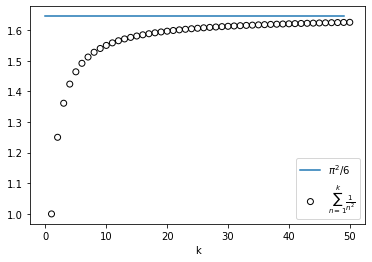

In [19]:
# run this once you've created the two needed arrays
plt.plot(asymptote, label = r"$\pi^2/6$")
plt.scatter(np.arange(1, n_max+1), 
            partial_sums, 
            label = r"$\sum_{n = 1}^k \frac{1}{n^2}$", 
            edgecolors = "black",
            facecolors = 'none')
plt.gca().set(xlabel = "k")
plt.legend()

If you've made it this far, great! If there are fewer than 10 minutes remaining in Discussion, feel free to submit your assignment. Otherwise, continue on to Exercise 3. 

---

## Exercise 3

The *law of large numbers* asserts that, if $X_1,\ldots,X_k$ is a sequence of independent and identically distributed random variables with mean $\mu$, then, if $k$ is sufficiently large, 
$$\frac{1}{k}\sum_{n = 1}^kX_n \approx \mu\;.$$

Here is some random data:

In [21]:
# run this block

k = 1000
a = np.random.randn(k) + np.random.randn()

Create a visualization, similar to the one in Exercise 2, that illustrates the law of large numbers for this data set. You'll need to first compute the required arrays. Then, you should copy/paste the visualization code from above, and see if you can figure out what to change. It's not necessary to worry about making attractive labels for the legend, but if you'd like to, you can use the raw strings `r"$\frac{1}{k}\sum_{n = 1}^k X_n$"` and `r"$\mu$"` for the series labels. 

<figure class="image" style="width:50%">
  <img src="https://raw.githubusercontent.com/PhilChodrow/PIC16A/master/discussion/numpy_practice_II-example-2.png" alt="">
  <figcaption><i>An example of what your output might look like. Yours will be slightly different, since we are working with random numbers.</i></figcaption>
</figure>

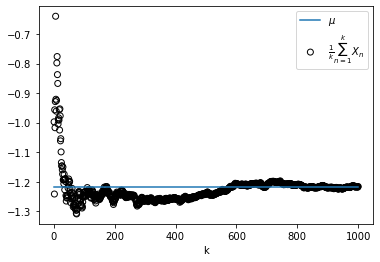

In [22]:
m = np.mean(a)*np.ones(k)
means = np.cumsum(a)/np.arange(1, k+1)

# run this once you've created the two needed arrays
plt.plot(m, label = r"$\mu$")
plt.scatter(np.arange(1, k+1), 
            means, 
            label = r"$\frac{1}{k}\sum_{n = 1}^k X_n$", 
            edgecolors = "black",
            facecolors = 'none')
plt.gca().set(xlabel = "k")
plt.legend()